In [ ]:
## Comparative Study of Optimizers in Deep Neural Networks (DNN) training with TensorFlow and the MNIST dataset

In [ ]:
"""
# Project title:
Examining optimizer effects on DNN training with TensorFlow and MNIST

# Core technologies:
Main tools and technologies are:
•	Python programming
•	Deep learning framework (TensorFlow and  Keras)
•	Libraries (numpy, matplotlib, MNIST data)
•	Coding environment (Anaconda setup (TensorFlow workspace), jupyter notebook)
•	Machine learning foundations (DNN, optimization methods, gradient descent approaches, image classification)

# Project objective:
Key objectives are:
•	Load MNIST data
•	Analyze data format
•	Prepare data through normalization and changing shape
•	Set up a DNN with TensorFlow and Keras  
•	Train the model with different optimizers   
•	Compare training loss patterns through epochs for different optimizers

"""

In [28]:
import tensorflow as tf

### Importing and preparing the MNIST dataset for model training

In [31]:
# Load the MNIST dataset

mnist_raw_dataset = tf.keras.datasets.mnist

# Do not normalize

(x_train_raw, y_train_raw), (x_test_raw, y_test_raw) = mnist_raw_dataset.load_data()

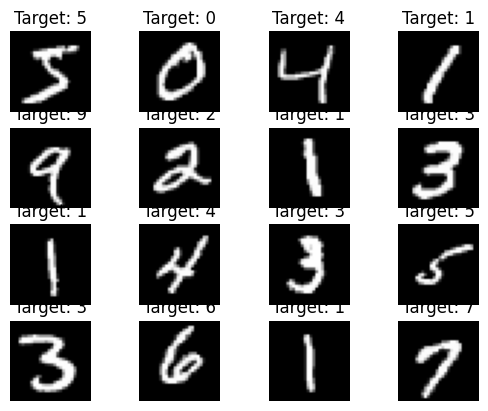

In [33]:
import matplotlib.pyplot as plt
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(x_train_raw[i], cmap='gray')
    plt.title(f'Target: {y_train_raw[i]}')
    plt.axis('off')

plt.show()

In [36]:
# Normalizing the pixel values of each MNIST image from 0-255 to 0-1.

(x_train, y_train), (x_test, y_test) = mnist_raw_dataset.load_data()

x_train = x_train / 255.0

x_test = x_test / 255.0

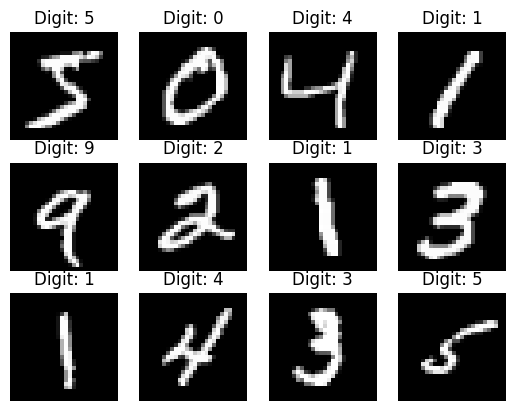

In [37]:
for a in range(12):
    plt.subplot(3, 4, a + 1)
    plt.imshow(x_train[a], cmap = 'gray')
    plt.title(f'Digit: {y_train[a]}')
    plt.axis('off')

plt.show()

In [41]:
# Reshaping the MNIST images from 28 x 28 pixels (2D matrix) into 784 pixels (1D vector).
# Each image represents 784 features.

x_train = x_train.reshape(-1, 28*28)
print(x_train.shape )

print()

x_test = x_test.reshape(-1, 28*28)
print(x_test.shape )

(60000, 784)

(10000, 784)


### Initialize a sequential mode (deep learning model)

In [53]:
# Input: 784 features; Hidden layers: 128 and 64 neurons with ReLU activation
# Output layer: 10 neurons with softmax activation for digit classification (0–9)


def create_neural_network_classification_model():
    sequential_model = tf.keras.Sequential ([tf.keras.layers.Dense(128, activation = 'relu', input_shape = (784,)),
                                             tf.keras.layers.Dense(64, activation = 'relu'),
                                             tf.keras.layers.Dense(10, activation = 'softmax')
                                            ])
    return sequential_model

### Comparison of different optimizers for training a neural network on MNIST

#### Choosing the best optimizer is crucial for minimizing loss and boosting the accuracy of deep neural network training.

In [57]:
"""
Gradient Descent, Stochastic Gradient Descent (SGD), and Mini-batch Gradient Descent use the Stochastic Gradient Descent (SGD) but the difference 
comes from batch size during training.
# Gradient Descent (Batch GD):  find the gradient with updating model weights using full training dataset.
# Stochastic Gradient Descent (SGD): Modify the model parameters using one data point per iteration.
# Mini-batch GD: Training the model with subset of training data  
# Adaptive Gradient (AdaGrad): Apply past gradient values to adjust the learning rate for each model parameter.
# Momentum Optimization:  Apply a velocity component built on past gradients calculated in prior iterations to reduce fluctuations and increase 
optimization speed. 
# Root Mean Square Propagation (RMSProp): Updates the learning rate using an average of the squared gradients.
# Adaptive Moment Estimation (Adam):  Combine momentum and RMSProp with keeping maintaining adaptive learning rates and using past gradients for 
accelerated convergence.
"""

comparison_optimizers ={'Batch Gradient Descent': tf.keras.optimizers.SGD(learning_rate = 0.01),
                        'Stochastic Gradient Descent (SGD)': tf.keras.optimizers.SGD(learning_rate = 0.01),
                        'Mini-batch Gradient Descent': tf.keras.optimizers.SGD(learning_rate = 0.01),
                        'AdaGrad Optimizer': tf.keras.optimizers.Adagrad(),
                        'Momentum SGD': tf.keras.optimizers.SGD(learning_rate = 0.01, momentum = 0.2),
                        'RMSProp Optimizer': tf.keras.optimizers.RMSprop(learning_rate = 0.001),
                        'Adam Optimizer': tf.keras.optimizers.Adam(learning_rate = 0.0001)
                       }

In [59]:

# Dictionary to save training results for each optimizer
training_results = {}

# Run training loop for each optimizer
for optimizer_name, optimizer_obj in comparison_optimizers.items():
    
    print(f'\nTraining the neural network with {optimizer_name} optimizer.\n')
    
    # Instantiate a model
    model = create_neural_network_classification_model()
    
    model.compile(optimizer= optimizer_obj,
                  loss = 'sparse_categorical_crossentropy',
                  metrics=['accuracy'
                          ])
    # Define batch size to illustrate full-batch, single-sample, and mini-batch training.

    if optimizer_name == 'Batch Gradient Descent':
        training_batch_size = 60000     # Use the full-batch (all data)
        
    elif optimizer_name == 'Stochastic Gradient Descent (SGD)':
        training_batch_size = 1    # Single data sample at a time
    else:
        training_batch_size = 32   # Mini-batch size

    # Train the neural network model
    training_history = model.fit(x_train, y_train, validation_split = 0.1, epochs = 8, batch_size = training_batch_size, verbose=0)

    # Save training history
    training_results[optimizer_name] = training_history


Training the neural network with Batch Gradient Descent optimizer.




Training the neural network with Stochastic Gradient Descent (SGD) optimizer.


Training the neural network with Mini-batch Gradient Descent optimizer.


Training the neural network with AdaGrad Optimizer optimizer.


Training the neural network with Momentum SGD optimizer.


Training the neural network with RMSProp Optimizer optimizer.


Training the neural network with Adam Optimizer optimizer.



### Comparison of training loss for different optimizers

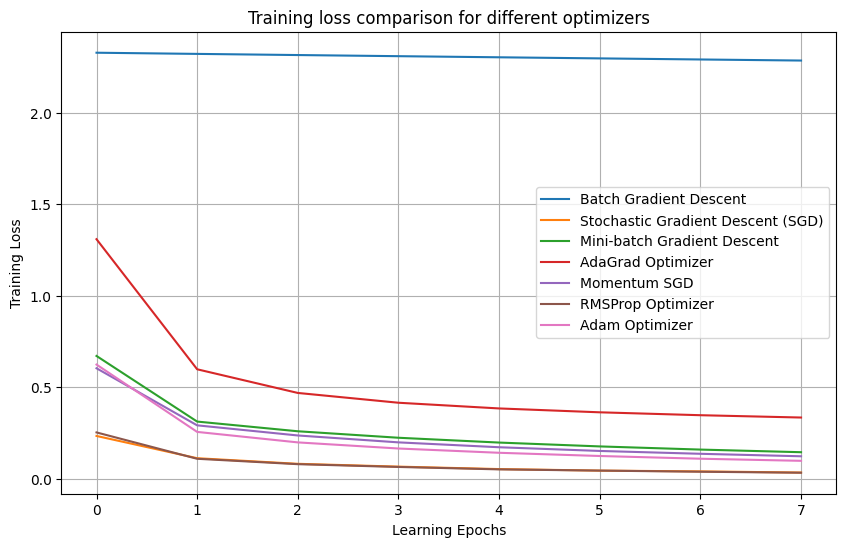

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize = (10,6))

for optimizer_name, history in training_results.items():
  plt.plot(history.history['loss'],label = optimizer_name)

plt.title('Training loss comparison for different optimizers')
plt.xlabel('Learning Epochs')
plt.ylabel('Training Loss')
plt.legend()
plt.grid(True)
plt.show()